In [1]:
import sys
sys.path.append("..")
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import load_from_disk
from src.llm_upgrade import wrap_for_transformer_lens

In [2]:
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'figure.figsize': (10, 6),
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'font.family': 'sans-serif',
    'mathtext.fontset': 'stix'
})

In [3]:
PROJECT_ROOT = Path("..")
PROBING_DIR = PROJECT_ROOT / "results/probing"
LOGIT_LENS_DIR = PROJECT_ROOT / "results/logit_lens"
TOKEN_SCORES_DIR = PROJECT_ROOT / "results/token_scores"
DATASET_PATH = PROJECT_ROOT / "data/processed/ruletaker_depth-0"

In [10]:
BASELINE_EXPS = {
    "pythia-depth-0": {
        "probing_json": PROBING_DIR / "probe_1b_depth-0_resid_post_last.json",
        "label": "Pythia-1B (depth-0, base)",
        "color": "#1f77b4", "marker": "o", "linestyle": ":", "arch": "pythia"
    },
    "pythia-depth-1": {
        "probing_json": PROBING_DIR / "probe_1b_depth-1_resid_post_last.json",
        "label": "Pythia-1B (depth-1, base)",
        "color": "#d62728", "marker": "D", "linestyle": ":", "arch": "pythia"
    },
    "gpt2-depth-0": {
        "probing_json": PROBING_DIR / "probe_gpt2-large_depth-0_resid_post_last.json",
        "label": "GPT-2 Large (depth-0, base)",
        "color": "#ff7f0e", "marker": "s", "linestyle": ":", "arch": "gpt2"
    },
    "gpt2-depth-1": {
        "probing_json": PROBING_DIR / "probe_gpt2-large_depth-1_resid_post_last.json",
        "label": "GPT-2 Large (depth-1, base)",
        "color": "#2ca02c", "marker": "^", "linestyle": ":", "arch": "gpt2"
    }
}

In [11]:
FINETUNED_EXPS = {
    "exp3-2": {
        "probing_json": PROBING_DIR / "probe_1b(qLoRA)_depth-0_resid_post_last.json",
        "logit_lens_json": LOGIT_LENS_DIR / "exp3-2_logit_lens.json",
        "model_name": "EleutherAI/pythia-1b-deduped",
        "adapter_path": PROJECT_ROOT / "results/checkpoints/finetune/exp3-2/checkpoint-6000",
        "label": "Pythia-1B (depth-0, QLoRA)",
        "color": "#1f77b4", "marker": "o", "arch": "pythia"
    },
    "exp6-1": {
        "probing_json": PROBING_DIR / "probe_gpt2-large(qLoRA)_depth-0_resid_post_last.json",
        "logit_lens_json": LOGIT_LENS_DIR / "exp6-1_logit_lens.json",
        "model_name": "gpt2-large",
        "adapter_path": PROJECT_ROOT / "results/checkpoints/finetune/exp6-1/checkpoint-11000",
        "label": "GPT-2 Large (depth-0, QLoRA)",
        "color": "#ff7f0e", "marker": "s", "arch": "gpt2"
    },
    "exp8-2": {
        "probing_json": PROBING_DIR / "probe_1b(seq_qlora)_depth-1_resid_post_last.json",
        "logit_lens_json": LOGIT_LENS_DIR / "exp8-2_logit_lens.json",
        "model_name": "EleutherAI/pythia-1b-deduped",
        "adapter_path": PROJECT_ROOT / "results/checkpoints/finetune/exp8-2/checkpoint-1000",
        "label": "Pythia-1B (depth-1, Seq QLoRA)",
        "color": "#d62728", "marker": "D", "arch": "pythia"
    },
    "exp7-2": {
        "probing_json": PROBING_DIR / "probe_gpt2-large(seq_qLoRA)_depth-1_resid_post_last.json",
        "logit_lens_json": LOGIT_LENS_DIR / "exp7-2_logit_lens.json",
        "model_name": "gpt2-large",
        "adapter_path": PROJECT_ROOT / "results/checkpoints/finetune/exp7-2/checkpoint-4000",
        "label": "GPT-2 Large (depth-1, Seq QLoRA)",
        "color": "#2ca02c", "marker": "^", "arch": "gpt2"
    }
}

In [8]:
def load_json(path):
    if not path.exists():
        print(f"Файл не найден: {path}")
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

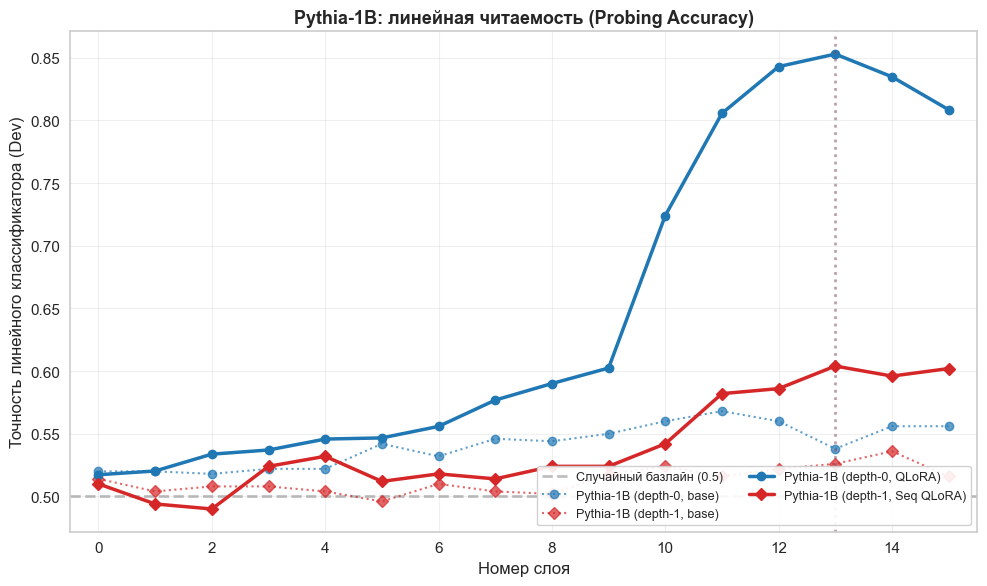

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Случайный базлайн (0.5)')

# Сначала базовые модели (пунктир, на заднем плане)
for exp_id, meta in BASELINE_EXPS.items():
    if meta["arch"] != "pythia":
        continue
    data = load_json(meta["probing_json"])
    if data is None:
        continue
    layers = data["layers"]
    dev_accs = data["dev_accs"]
    ax.plot(layers, dev_accs, label=meta["label"],
            color=meta["color"], marker=meta["marker"],
            linestyle=meta.get("linestyle", ":"), linewidth=1.5, alpha=0.7)

# Затем дообученные модели (сплошная линия, на переднем плане)
for exp_id, meta in FINETUNED_EXPS.items():
    if meta["arch"] != "pythia":
        continue
    data = load_json(meta["probing_json"])
    if data is None:
        continue
    layers = data["layers"]
    dev_accs = data["dev_accs"]
    ax.plot(layers, dev_accs, label=meta["label"],
            color=meta["color"], marker=meta["marker"],
            linestyle='-', linewidth=2.5)
    # Вертикальная отметка лучшего слоя
    best_layer = data["summary"]["best_layer"]
    ax.axvline(best_layer, color=meta["color"], linestyle=':', alpha=0.3)

ax.set_xlabel("Номер слоя", fontsize=12)
ax.set_ylabel("Точность линейного классификатора (Dev)", fontsize=12)
ax.set_title("Pythia-1B: линейная читаемость (Probing Accuracy)", fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='lower right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 15.5)  # Pythia имеет 16 слоёв (0–15)
plt.tight_layout()
plt.show()

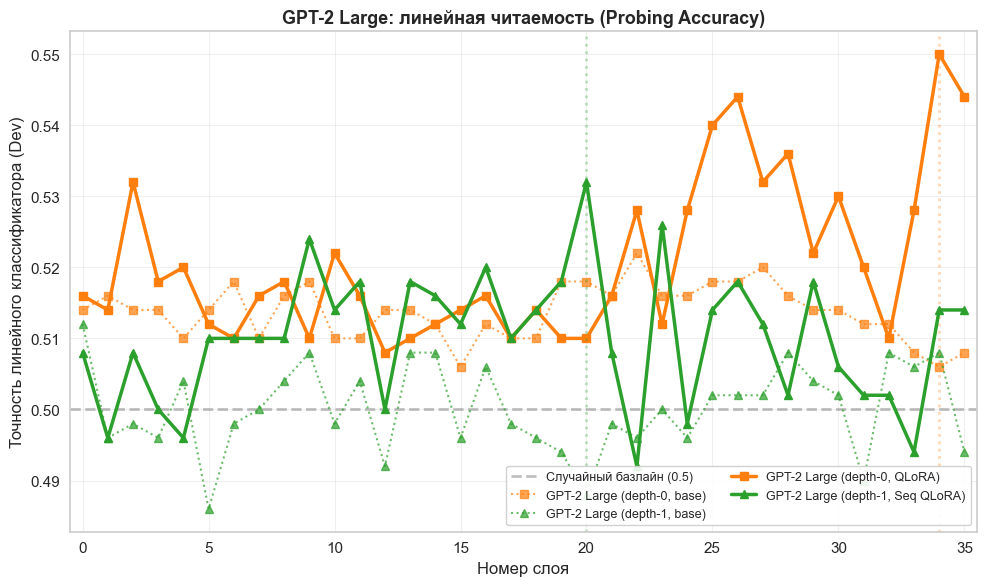

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Случайный базлайн (0.5)')

# Сначала базовые модели (пунктир, на заднем плане)
for exp_id, meta in BASELINE_EXPS.items():
    if meta["arch"] != "gpt2":
        continue
    data = load_json(meta["probing_json"])
    if data is None:
        continue
    layers = data["layers"]
    dev_accs = data["dev_accs"]
    ax.plot(layers, dev_accs, label=meta["label"],
            color=meta["color"], marker=meta["marker"],
            linestyle=meta.get("linestyle", ":"), linewidth=1.5, alpha=0.7)

# Затем дообученные модели (сплошная линия, на переднем плане)
for exp_id, meta in FINETUNED_EXPS.items():
    if meta["arch"] != "gpt2":
        continue
    data = load_json(meta["probing_json"])
    if data is None:
        continue
    layers = data["layers"]
    dev_accs = data["dev_accs"]
    ax.plot(layers, dev_accs, label=meta["label"],
            color=meta["color"], marker=meta["marker"],
            linestyle='-', linewidth=2.5)
    # Вертикальная отметка лучшего слоя
    best_layer = data["summary"]["best_layer"]
    ax.axvline(best_layer, color=meta["color"], linestyle=':', alpha=0.3)

ax.set_xlabel("Номер слоя", fontsize=12)
ax.set_ylabel("Точность линейного классификатора (Dev)", fontsize=12)
ax.set_title("GPT-2 Large: линейная читаемость (Probing Accuracy)", fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='lower right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 35.5)  # GPT-2 Large имеет 36 слоёв (0–35)
plt.tight_layout()
plt.show()

In [14]:
exp_key = "exp8-2"
meta = FINETUNED_EXPS[exp_key]
data = load_json(meta["probing_json"])

In [15]:
if data and "diff_stats" in data:
    neuron_sens = np.array(data["diff_stats"]["neuron_sensitivity"])
    top_k = 20
    top_indices = np.argsort(neuron_sens)[-top_k:][::-1]
    top_scores = neuron_sens[top_indices]
    top_neuron_ids = [int(i) for i in top_indices]

    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(top_k)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_k))
    ax.barh(y_pos, top_scores, color=colors, edgecolor="black", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"Neuron {n}" for n in top_neuron_ids])
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Средняя абсолютная разница активаций (минимальные пары)")
    ax.set_title(f"Топ-{top_k} чувствительных нейронов\n{meta['label']} | слой {data['summary']['best_layer']}")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Поле diff_stats отсутствует в {exp_key}. Запустите ячейку разностного анализа в probing-ноутбуке.")

⚠️ Поле diff_stats отсутствует в exp8-2. Запустите ячейку разностного анализа в probing-ноутбуке.
